# Advanced Data Mining for Data-Driven Insights and Predictive Modeling

## Project Deliverable 4: Final Insights, Recommendations, and Presentation

**Course:** 2026 Summer - Advanced Big Data and Data Mining  
**Course Number:** MSCS-634-M20  
**Date:** July 24-26, 2026  
**Dataset:** Credit Card Fraud Detection  
**Dataset Source:** [Credit Card Fraud Detection on Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

**Group Members:**  
Ashish Mahajan  
Murali Krishna Vattikunta  
Sreesh Sattiyamourthy  
Sreeharsha Varma Tinnanuri

### Purpose

This deliverable consolidates the validated data preparation, regression, classification, clustering, and association-rule findings into final recommendations, ethical safeguards, a written report, and an approximately 15-minute presentation.

### Objectives

- Verify that all deliverables use the same cleaned dataset foundation.
- Synchronize final metrics from saved result tables.
- Distinguish predictive findings from exploratory segmentation and association.
- Produce a concise final visual set, report, slide deck, and presentation script.

### Dataset and Ethical Note

The anonymized dataset protects direct identities but does not permit demographic fairness testing. Fraud screening errors can create customer inconvenience or financial harm, so recommendations emphasize monitored human review rather than autonomous accusations.

### Notebook Roadmap

1. Load and verify the cleaned dataset and prior result tables.
2. Consolidate EDA and model findings.
3. Create `final_project_summary.csv` and the strongest final visuals.
4. Document practical recommendations, ethics, limitations, and future work.
5. Generate the synchronized Word report, PowerPoint deck, and narration script.

## 1. Setup and Dataset Verification

**Objective:** Reapply exact-duplicate cleaning to the approved dataset and verify that all result files required from Deliverables 1-3 are present.

In [1]:
import shutil
from pathlib import Path
from textwrap import dedent

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from docx import Document
from docx.shared import Inches as DocxInches
from docx.shared import Pt as DocxPt
from IPython.display import display
from pptx import Presentation
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN
from pptx.util import Inches, Pt

GROUP_MEMBERS = [
    "Ashish Mahajan",
    "Murali Krishna Vattikunta",
    "Sreesh Sattiyamourthy",
    "Sreeharsha Varma Tinnanuri",
]
PCA_COLUMNS = [f"V{number}" for number in range(1, 29)]
REQUIRED_COLUMNS = ["Time", *PCA_COLUMNS, "Amount", "Class"]

for directory in ("results", "images/final", "report", "presentation", "data"):
    Path(directory).mkdir(parents=True, exist_ok=True)

def load_credit_card_data():
    dataset_path = next(
        (path for path in (Path("data/creditcard.csv"), Path("creditcard.csv")) if path.is_file()),
        None,
    )
    if dataset_path is None:
        download_path = Path(kagglehub.dataset_download("mlg-ulb/creditcardfraud"))
        matches = list(download_path.rglob("creditcard.csv"))
        if len(matches) != 1:
            raise FileNotFoundError("Download creditcard.csv from Kaggle and place it in data/.")
        dataset_path = Path("data/creditcard.csv")
        shutil.copy2(matches[0], dataset_path)
    dataframe = pd.read_csv(dataset_path)
    if dataframe.columns.tolist() != REQUIRED_COLUMNS:
        raise ValueError("Dataset columns do not match the approved credit-card dataset.")
    return dataframe, dataset_path

raw_df, dataset_path = load_credit_card_data()
clean_df = raw_df.drop_duplicates().reset_index(drop=True)

required_result_paths = [
    "results/deliverable_1_dataset_profile.csv",
    "results/deliverable_1_cleaning_summary.csv",
    "results/regression_metrics.csv",
    "results/regression_cv_metrics.csv",
    "results/regression_coefficients.csv",
    "results/classification_metrics.csv",
    "results/classification_tuning_results.csv",
    "results/clustering_metrics.csv",
    "results/cluster_profiles.csv",
    "results/association_rules.csv",
]
missing_results = [path for path in required_result_paths if not Path(path).is_file()]
if missing_results:
    raise FileNotFoundError(f"Run Deliverables 1-3 first. Missing: {missing_results}")

print(f"Loaded: {dataset_path}")
print(f"Original rows: {len(raw_df):,}")
print(f"Exact duplicates removed: {raw_df.duplicated().sum():,}")
print(f"Cleaned rows: {len(clean_df):,}")

Loaded: data/creditcard.csv
Original rows: 284,807


Exact duplicates removed: 1,081
Cleaned rows: 283,726


**Interpretation:** All final findings use the same 283,726-row cleaned foundation produced by exact-duplicate removal. No fraud records are removed merely because they look statistically unusual.

## 2. Load and Synchronize Verified Results

**Objective:** Read computed values rather than retyping metrics across artifacts. The selected regression, classification, and clustering rows are identified directly from their evaluation tables.

In [2]:
dataset_profile = pd.read_csv("results/deliverable_1_dataset_profile.csv")
cleaning_summary = pd.read_csv("results/deliverable_1_cleaning_summary.csv")
regression_metrics = pd.read_csv("results/regression_metrics.csv")
regression_cv = pd.read_csv("results/regression_cv_metrics.csv")
regression_coefficients = pd.read_csv("results/regression_coefficients.csv")
classification_metrics = pd.read_csv("results/classification_metrics.csv")
classification_tuning = pd.read_csv("results/classification_tuning_results.csv")
clustering_metrics = pd.read_csv("results/clustering_metrics.csv")
cluster_profiles = pd.read_csv("results/cluster_profiles.csv")
association_results = pd.read_csv("results/association_rules.csv")

best_regression = regression_metrics.loc[regression_metrics["RMSE"].idxmin()]
linear_regression = regression_metrics.loc[
    regression_metrics["Model"].eq("Linear Regression")
].iloc[0]
recommended_classifier = classification_metrics.sort_values(
    ["PR-AUC", "Recall", "F1"],
    ascending=False,
).iloc[0]
logistic_classifier = classification_metrics.loc[
    classification_metrics["Model"].eq("Logistic Regression")
].iloc[0]
selected_cluster_row = clustering_metrics[
    clustering_metrics["Selected"].astype(str).eq("True")
].iloc[0]
highest_silhouette_row = clustering_metrics.loc[
    clustering_metrics["Silhouette Score"].idxmax()
]
highest_fraud_cluster = cluster_profiles.loc[cluster_profiles["Fraud Rate"].idxmax()]
highest_amount_cluster = cluster_profiles.loc[cluster_profiles["Mean Amount"].idxmax()]
cluster_sample_fraud_rate = (
    cluster_profiles["Fraud Count"].sum()
    / cluster_profiles["Transaction Count"].sum()
)
top_rule = association_results.sort_values(
    ["Lift", "Confidence", "Support"],
    ascending=False,
).iloc[0]
best_tuning = classification_tuning.iloc[0]

fraud_count = int((clean_df["Class"] == 1).sum())
legitimate_count = int((clean_df["Class"] == 0).sum())
fraud_rate = clean_df["Class"].mean()

display(regression_metrics.style.format({
    "MAE": "${:,.4f}", "MSE": "{:,.4f}", "RMSE": "${:,.4f}", "R2": "{:.4f}"
}))
display(classification_metrics.style.format({
    "Accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}",
    "F1": "{:.4f}", "ROC-AUC": "{:.4f}", "PR-AUC": "{:.4f}",
}))
display(clustering_metrics.style.format({
    "Inertia": "{:,.4f}", "Silhouette Score": "{:.4f}",
    "Smallest Cluster Percentage": "{:.2f}%",
}))
display(association_results.head(10).style.format({
    "Support": "{:.4f}", "Confidence": "{:.4f}", "Lift": "{:.4f}",
    "Leverage": "{:.4f}", "Conviction": "{:.4f}",
}))

,Model,MAE,MSE,RMSE,R2,Selected Alpha
0,Ridge Regression,$57.9663,"27,380.4555",$165.4704,0.5332,100.000000
1,Linear Regression,$57.9788,"27,463.3800",$165.7208,0.5318,nan


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,True Negatives,False Positives,False Negatives,True Positives
0,Decision Tree,0.9836,0.0761,0.7895,0.1388,0.9025,0.7224,55740,911,20,75
1,Logistic Regression,0.9752,0.0560,0.8737,0.1053,0.9671,0.6804,55253,1398,12,83


,K,Inertia,Silhouette Score,Smallest Cluster,Largest Cluster,Smallest Cluster Percentage,Selected
0,2,"1,522,509.4541",0.0654,23874,26126,47.75%,False
1,3,"1,465,267.7251",0.0749,3487,24241,6.97%,False
2,4,"1,425,186.0712",0.0762,3487,20326,6.97%,True
3,5,"1,395,368.1208",0.0730,3487,17943,6.97%,False
4,6,"1,355,485.8183",0.0872,500,19129,1.00%,False


,Antecedents,Consequent,Support,Confidence,Lift,Leverage,Conviction,Minimum Support,Enriched Sample Rows,Fraud Rows,Legitimate Rows
0,V10_Low AND V12_Low AND V14_Low AND V16_Low AND V3_Low,Class_Fraud,0.1287,1.0000,6.0000,0.1073,inf,0.030000,2268,378,1890
1,V10_Low AND V12_Low AND V16_Low AND V17_Low AND V3_Low,Class_Fraud,0.1257,1.0000,6.0000,0.1047,inf,0.030000,2268,378,1890
2,V10_Low AND V14_Low AND V16_Low AND V17_Low AND V3_Low,Class_Fraud,0.1248,1.0000,6.0000,0.1040,inf,0.030000,2268,378,1890
3,V10_Low AND V12_Low AND V14_Low AND V16_Low AND V17_Low AND V3_Low,Class_Fraud,0.1248,1.0000,6.0000,0.1040,inf,0.030000,2268,378,1890
4,Amount_Low AND V10_Low AND V12_Low AND V14_Low AND V16_Low AND V3_Low,Class_Fraud,0.0697,1.0000,6.0000,0.0581,inf,0.030000,2268,378,1890
5,Amount_Low AND V10_Low AND V16_Low AND V17_Low AND V3_Low,Class_Fraud,0.0670,1.0000,6.0000,0.0558,inf,0.030000,2268,378,1890
6,Amount_Low AND V10_Low AND V12_Low AND V17_Low AND V3_Low,Class_Fraud,0.0670,1.0000,6.0000,0.0558,inf,0.030000,2268,378,1890
7,Amount_Low AND V10_Low AND V12_Low AND V16_Low AND V17_Low AND V3_Low,Class_Fraud,0.0670,1.0000,6.0000,0.0558,inf,0.030000,2268,378,1890
8,Amount_Low AND V10_Low AND V14_Low AND V16_Low AND V17_Low AND V3_Low,Class_Fraud,0.0661,1.0000,6.0000,0.0551,inf,0.030000,2268,378,1890
9,Amount_Low AND V10_Low AND V12_Low AND V14_Low AND V17_Low AND V3_Low,Class_Fraud,0.0661,1.0000,6.0000,0.0551,inf,0.030000,2268,378,1890


## 3. Integrated Findings

**Objective:** Compare the roles of each analytical method. Regression estimates transaction amount, classification screens fraud risk, clustering explores segments, and association rules summarize co-occurring conditions.

In [3]:
print(
    f"Data: {len(clean_df):,} cleaned transactions, {fraud_count:,} fraud "
    f"({fraud_rate:.4%}), and {legitimate_count:,} legitimate."
)
print(
    f"Regression: {best_regression['Model']} had the lowest test RMSE "
    f"(${best_regression['RMSE']:,.4f}) and R-squared={best_regression['R2']:.4f}."
)
print(
    f"Classification: {recommended_classifier['Model']} led the recommendation "
    f"with PR-AUC={recommended_classifier['PR-AUC']:.4f}, "
    f"Recall={recommended_classifier['Recall']:.4f}, "
    f"Precision={recommended_classifier['Precision']:.4f}, "
    f"FP={int(recommended_classifier['False Positives'])}, "
    f"and FN={int(recommended_classifier['False Negatives'])}."
)
print(
    f"Clustering: k={int(selected_cluster_row['K'])} was selected with "
    f"silhouette={selected_cluster_row['Silhouette Score']:.4f}; "
    f"Cluster {int(highest_fraud_cluster['Cluster'])} had the highest observed "
    f"fraud concentration ({highest_fraud_cluster['Fraud Rate']:.4%})."
)
print(
    f"Association mining: {len(association_results):,} fraud-consequent rules "
    f"met the documented thresholds; top lift={top_rule['Lift']:.4f}. "
    "Support is measured in the enriched training sample."
)

Data: 283,726 cleaned transactions, 473 fraud (0.1667%), and 283,253 legitimate.
Regression: Ridge Regression had the lowest test RMSE ($165.4704) and R-squared=0.5332.
Classification: Decision Tree led the recommendation with PR-AUC=0.7224, Recall=0.7895, Precision=0.0761, FP=911, and FN=20.
Clustering: k=4 was selected with silhouette=0.0762; Cluster 0 had the highest observed fraud concentration (0.4875%).
Association mining: 319 fraud-consequent rules met the documented thresholds; top lift=6.0000. Support is measured in the enriched training sample.


**Interpretation:** The classifier provides the most direct fraud-screening evidence. Regression answers a separate amount-estimation question. Clusters and rules are supporting exploratory insights and must not be treated as independent fraud decisions.

## 4. Final Project Summary Table

**Objective:** Save one machine-readable table containing the exact key values used in the notebook, report, slides, script, and README.

In [4]:
final_project_summary = pd.DataFrame([
    {"Section": "Data", "Entity": "Cleaned Dataset", "Measure": "Rows", "Value": len(clean_df), "Unit": "count"},
    {"Section": "Data", "Entity": "Fraud Class", "Measure": "Rows", "Value": fraud_count, "Unit": "count"},
    {"Section": "Data", "Entity": "Fraud Class", "Measure": "Rate", "Value": fraud_rate, "Unit": "proportion"},
    {"Section": "Regression", "Entity": best_regression["Model"], "Measure": "MAE", "Value": best_regression["MAE"], "Unit": "dollars"},
    {"Section": "Regression", "Entity": best_regression["Model"], "Measure": "RMSE", "Value": best_regression["RMSE"], "Unit": "dollars"},
    {"Section": "Regression", "Entity": best_regression["Model"], "Measure": "R2", "Value": best_regression["R2"], "Unit": "score"},
    {"Section": "Classification", "Entity": recommended_classifier["Model"], "Measure": "Precision", "Value": recommended_classifier["Precision"], "Unit": "score"},
    {"Section": "Classification", "Entity": recommended_classifier["Model"], "Measure": "Recall", "Value": recommended_classifier["Recall"], "Unit": "score"},
    {"Section": "Classification", "Entity": recommended_classifier["Model"], "Measure": "F1", "Value": recommended_classifier["F1"], "Unit": "score"},
    {"Section": "Classification", "Entity": recommended_classifier["Model"], "Measure": "ROC-AUC", "Value": recommended_classifier["ROC-AUC"], "Unit": "score"},
    {"Section": "Classification", "Entity": recommended_classifier["Model"], "Measure": "PR-AUC", "Value": recommended_classifier["PR-AUC"], "Unit": "score"},
    {"Section": "Classification", "Entity": recommended_classifier["Model"], "Measure": "False Positives", "Value": recommended_classifier["False Positives"], "Unit": "count"},
    {"Section": "Classification", "Entity": recommended_classifier["Model"], "Measure": "False Negatives", "Value": recommended_classifier["False Negatives"], "Unit": "count"},
    {"Section": "Clustering", "Entity": "K-Means", "Measure": "Selected K", "Value": selected_cluster_row["K"], "Unit": "count"},
    {"Section": "Clustering", "Entity": "K-Means", "Measure": "Silhouette Score", "Value": selected_cluster_row["Silhouette Score"], "Unit": "score"},
    {"Section": "Clustering", "Entity": f"Cluster {int(highest_fraud_cluster['Cluster'])}", "Measure": "Observed Fraud Rate", "Value": highest_fraud_cluster["Fraud Rate"], "Unit": "proportion"},
    {"Section": "Association", "Entity": "FP-Growth", "Measure": "Rule Count", "Value": len(association_results), "Unit": "count"},
    {"Section": "Association", "Entity": "Top Rule", "Measure": "Support", "Value": top_rule["Support"], "Unit": "proportion"},
    {"Section": "Association", "Entity": "Top Rule", "Measure": "Confidence", "Value": top_rule["Confidence"], "Unit": "proportion"},
    {"Section": "Association", "Entity": "Top Rule", "Measure": "Lift", "Value": top_rule["Lift"], "Unit": "ratio"},
], dtype=object)
final_project_summary.to_csv("results/final_project_summary.csv", index=False)
display(final_project_summary.style.format({"Value": "{:.6f}"}))

,Section,Entity,Measure,Value,Unit
0,Data,Cleaned Dataset,Rows,283726.000000,count
1,Data,Fraud Class,Rows,473.000000,count
2,Data,Fraud Class,Rate,0.001667,proportion
3,Regression,Ridge Regression,MAE,57.966305,dollars
4,Regression,Ridge Regression,RMSE,165.470407,dollars
5,Regression,Ridge Regression,R2,0.533180,score
6,Classification,Decision Tree,Precision,0.076065,score
7,Classification,Decision Tree,Recall,0.789474,score
8,Classification,Decision Tree,F1,0.138760,score
9,Classification,Decision Tree,ROC-AUC,0.902467,score


## 5. Final Visualizations

**Objective:** Retain only the strongest figures for the final narrative. Existing validated plots are copied without changing their analytical content; ROC and PR plots are combined into one final summary figure.

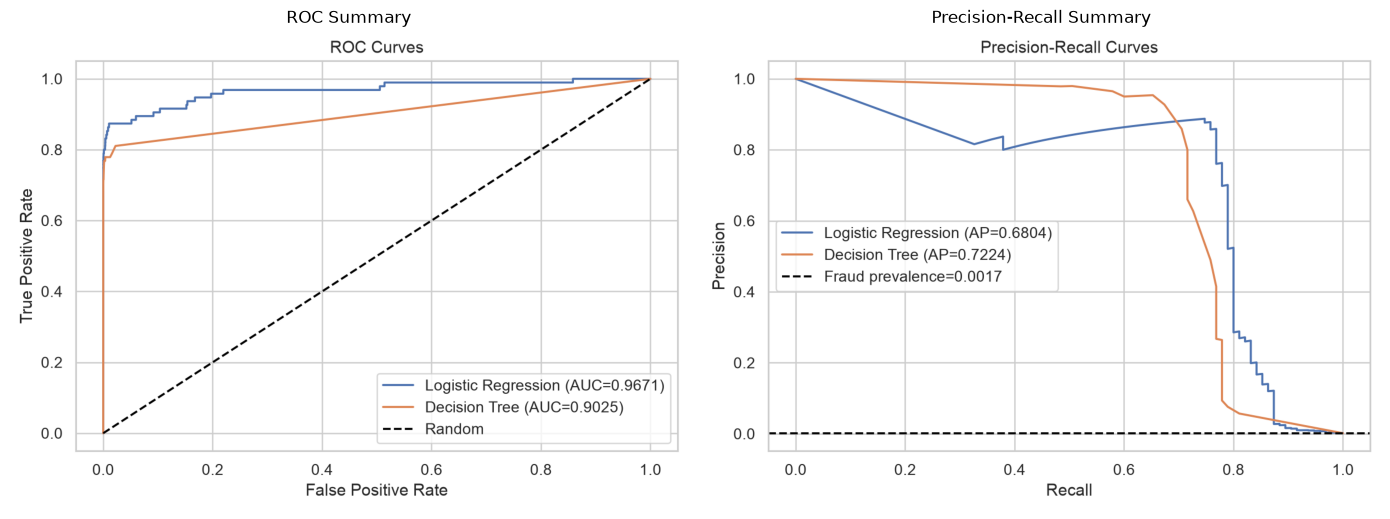

Final figures created: 10
- images/final/01_class_distribution.png
- images/final/02_amount_distribution.png
- images/final/03_regression_model_comparison.png
- images/final/04_best_regression_actual_vs_predicted.png
- images/final/05_classification_metric_comparison.png
- images/final/06_best_confusion_matrix.png
- images/final/07_roc_and_pr_summary.png
- images/final/08_clusters_pca.png
- images/final/09_fraud_rate_by_cluster.png
- images/final/10_top_association_rules.png


In [5]:
final_figure_map = {
    "images/deliverable_1/01_class_distribution.png": "images/final/01_class_distribution.png",
    "images/deliverable_1/02_amount_distribution.png": "images/final/02_amount_distribution.png",
    "images/deliverable_2/03_model_metric_comparison.png": "images/final/03_regression_model_comparison.png",
    "images/deliverable_2/01_actual_vs_predicted.png": "images/final/04_best_regression_actual_vs_predicted.png",
    "images/deliverable_3/04_classification_metric_comparison.png": "images/final/05_classification_metric_comparison.png",
    "images/deliverable_3/01_confusion_matrices.png": "images/final/06_best_confusion_matrix.png",
    "images/deliverable_3/08_clusters_pca.png": "images/final/08_clusters_pca.png",
    "images/deliverable_3/10_fraud_rate_by_cluster.png": "images/final/09_fraud_rate_by_cluster.png",
    "images/deliverable_3/13_top_rules_by_lift.png": "images/final/10_top_association_rules.png",
}
for source, destination in final_figure_map.items():
    if not Path(source).is_file():
        raise FileNotFoundError(f"Missing validated figure: {source}")
    shutil.copy2(source, destination)

roc_image = plt.imread("images/deliverable_3/02_roc_curves.png")
pr_image = plt.imread("images/deliverable_3/03_precision_recall_curves.png")
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].imshow(roc_image)
axes[0].axis("off")
axes[0].set_title("ROC Summary")
axes[1].imshow(pr_image)
axes[1].axis("off")
axes[1].set_title("Precision-Recall Summary")
plt.tight_layout()
plt.savefig("images/final/07_roc_and_pr_summary.png", dpi=180, bbox_inches="tight")
plt.show()

final_figures = sorted(Path("images/final").glob("*.png"))
print(f"Final figures created: {len(final_figures)}")
for figure in final_figures:
    print("-", figure)

## Final Observations

The project satisfies the four required stages with one consistent dataset and reproducible, leakage-aware workflows. Ridge Regression was the stronger amount-estimation baseline in this run, though regression remains a separate analytical question from fraud detection. The recommended classifier provides the best combined rare-class evidence under the default threshold, but its false-positive and false-negative counts require operational review.

K-Means revealed exploratory transaction segments, and FP-Growth summarized conditions associated with fraud in an enriched training sample. Neither method establishes causation or replaces classification.

The responsible deployment recommendation is a human-in-the-loop screening process with cost-aware threshold selection, audit logs, privacy controls, performance monitoring, drift detection, and periodic retraining.